In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from jupyterlab.semver import regexp
from sklearn import datasets
import seaborn as sns

In [5]:
df = pd.read_csv('/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/1-studyhours.csv')
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


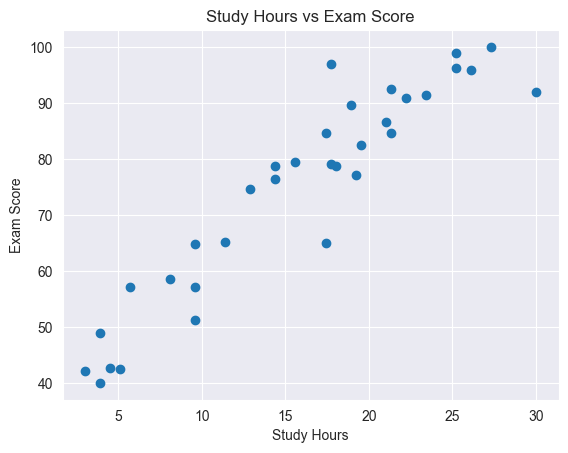

In [7]:
plt.scatter(df['Study Hours'], df['Exam Score'])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.show()

In [8]:
# independent (input) and dependent (output) features
X = df[['Study Hours']] # 2D array for a single feature
y = df['Exam Score'] # 1D array

In [9]:
type(X)

pandas.core.frame.DataFrame

In [10]:
type(y)

pandas.core.series.Series

In [11]:
# test - train split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test
#X_train and y_train are used to train the model len = 26 (for 33 samples)
#X_test and y_test are used to evaluate the model len = 7 (for 33 samples)
# X_tain + X_test = total x len = 33
# y_tain + y_test = total y len = 33

In [12]:
X_test

,Study Hours
31,25.2
15,17.7
26,9.6
17,12.9
8,25.2
9,17.4
19,21.3


In [13]:
# Standardize the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit and transform the training data
X_test = scaler.transform(X_test) # only transform the test data

In [14]:
X_train

array([[-0.89166498],
       [ 1.91959769],
       [-1.43081124],
       [-0.08294558],
       [-1.19974856],
       [ 0.37917979],
       [ 1.57300366],
       [ 1.41896187],
       [-0.69911274],
       [-0.69911274],
       [-1.35379035],
       [ 0.57173203],
       [-0.46805005],
       [ 0.07109621],
       [-1.54634258],
       [ 1.07236785],
       [-0.08294558],
       [ 0.3021589 ],
       [-1.27676945],
       [ 0.53322158],
       [-1.43081124],
       [ 0.49471113],
       [ 0.91832606],
       [ 0.80279471],
       [ 0.76428427],
       [ 0.34066934]])

In [15]:
X_test

array([[ 1.30343053],
       [ 0.34066934],
       [-0.69911274],
       [-0.27549782],
       [ 1.30343053],
       [ 0.3021589 ],
       [ 0.80279471]])

In [16]:
# Training the Model with Linear Regression

from sklearn.linear_model import LinearRegression

In [17]:
regression = LinearRegression()

In [18]:
regression.fit(X_train, y_train) # training the model with training data X_train girdileri ve y_train çıktılarını veriyor bunu model öğreniyor

LinearRegression()

In [19]:
print("Coefficient:", regression.coef_) # slope of the line x in y = mx + b
print("Intercept:", regression.intercept_) # y-intercept of the line # y = mx + b
# y = 17.77 x + 71.58

Coefficient: [17.77325513]
Intercept: 71.58461538461538


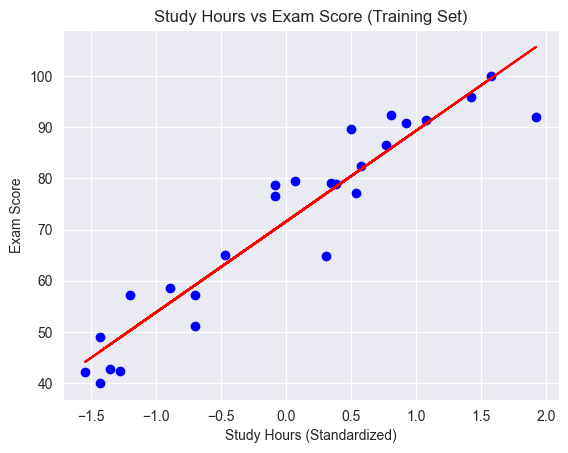

In [20]:
plt.scatter(X_train, y_train, color='blue') # training data points
plt.plot(X_train, regression.predict(X_train), color='red') # prediction line on training data by learned model with linear regression
plt.xlabel('Study Hours (Standardized)')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score (Training Set)')
plt.show()

In [21]:
# Let's make predictions on the test set
# x = 20 hours => y = ?

y_pred = regression.predict(scaler.transform([[20]])) # remember to standardize the input
print("Predicted Exam Score for 2.5 Study Hours:", y_pred)

Predicted Exam Score for 2.5 Study Hours: [82.8869146]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# predicting the test set results
y_pred_test = regression.predict(X_test)

In [23]:
# Evaluating the Model
y_test

31    96.2
15    97.0
26    64.8
17    74.7
8     99.0
9     84.6
19    84.7
Name: Exam Score, dtype: float64

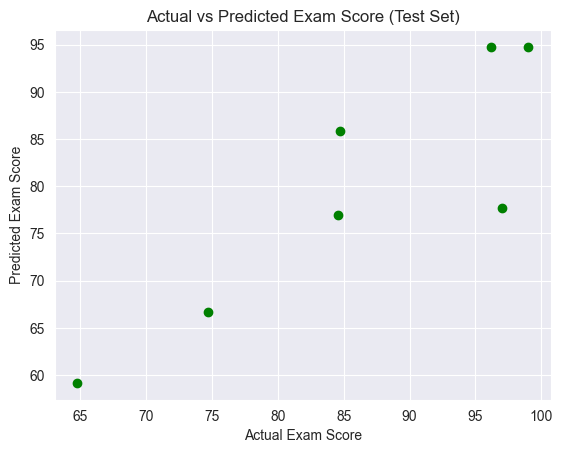

In [24]:
plt.scatter(y_test, y_pred_test, color='green')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Score (Test Set)')
#plt.plot([0, 100], [0, 100], color='red', linestyle='--') # diagonal line
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
mse = mean_squared_error(y_test, y_pred_test) # mean squared error
mae = mean_absolute_error(y_test, y_pred_test) # mean absolute error
r2 = r2_score(y_test, y_pred_test) # R-squared score
rmse = np.sqrt(mse) # root mean squared error

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 78.68191446465701
Mean Absolute Error: 6.787091909266651
R-squared Score: 0.4349170848122318
Root Mean Squared Error: 8.870282659794839
